# Hotel Review Sentiment Analysis - Training Notebook
This notebook covers the full ML pipeline: data loading, preprocessing, EDA, model training, evaluation, and saving.

Dataset: 515K Hotel Reviews Data in Europe
Author: Jiashen Liu
Source: Kaggle
Accessed on: July 2025

The dataset contains over 500,000 reviews of hotels across Europe, labeled by sentiment (positive/negative) and includes associated metadata such as reviewer nationalities, hotel names, and more.

🔗 Kaggle Dataset Link

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib

import warnings
warnings.filterwarnings("ignore")


In [5]:
# Load hotel reviews dataset
df = pd.read_csv("C:/Users/knowl/OneDrive/Desktop/hotel_ai_agent/data/Hotel_Reviews.csv")
df.head()


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [6]:
# Check data types and missing values
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64

In [7]:
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


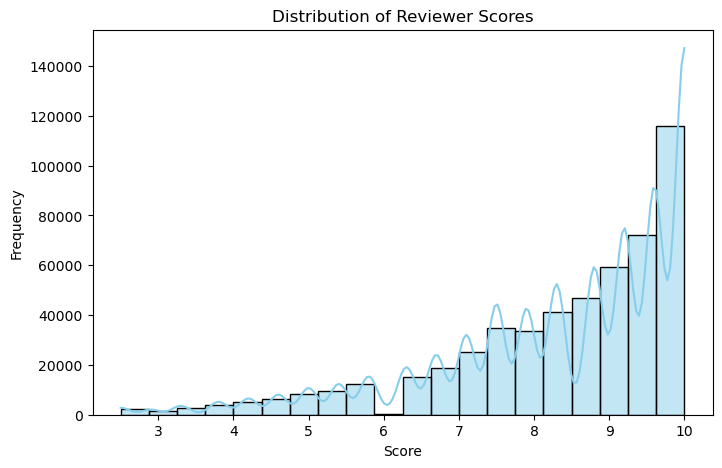

In [8]:
#  Distribution of Reviewer Scores
plt.figure(figsize=(8, 5))
sns.histplot(df['Reviewer_Score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Reviewer Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

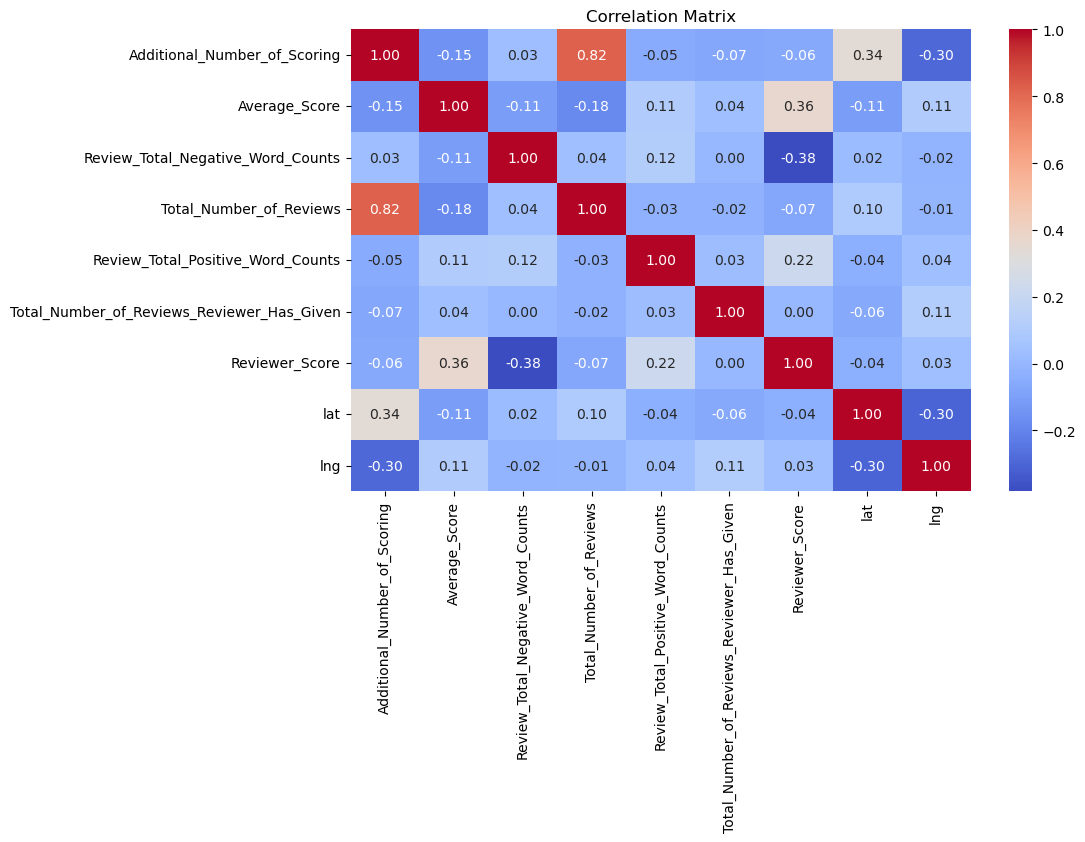

In [9]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

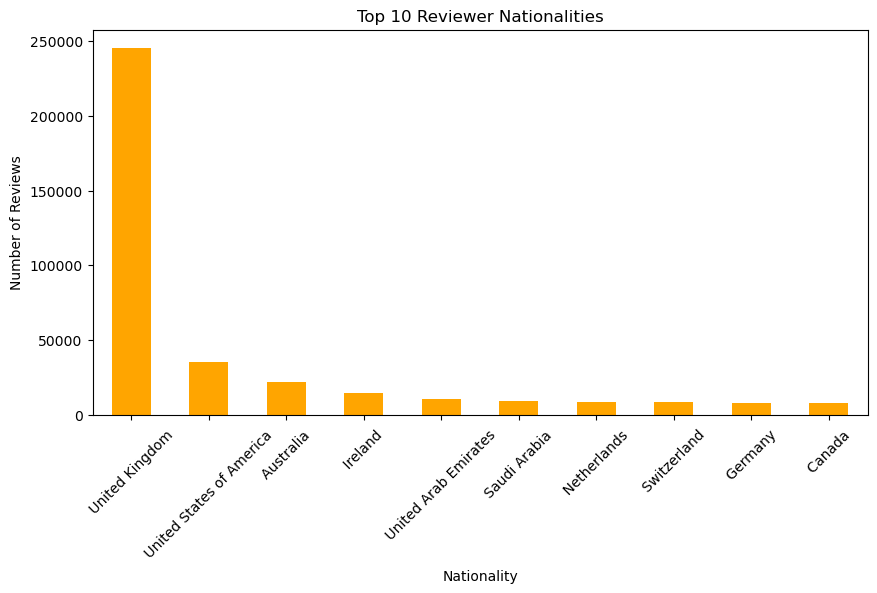

In [10]:
# Top 10 Nationalities by Review Count
plt.figure(figsize=(10, 5))
df['Reviewer_Nationality'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Reviewer Nationalities')
plt.ylabel('Number of Reviews')
plt.xlabel('Nationality')
plt.xticks(rotation=45)
plt.show()

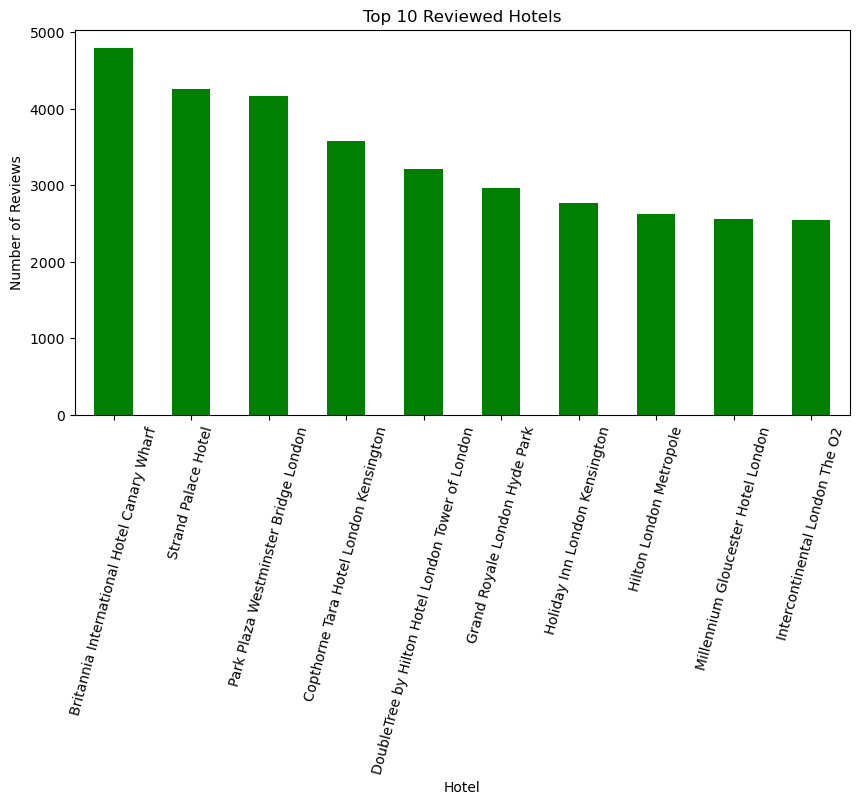

In [11]:

# Hotel with Most Reviews
plt.figure(figsize=(10, 5))
df['Hotel_Name'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top 10 Reviewed Hotels')
plt.ylabel('Number of Reviews')
plt.xlabel('Hotel')
plt.xticks(rotation=75)
plt.show()


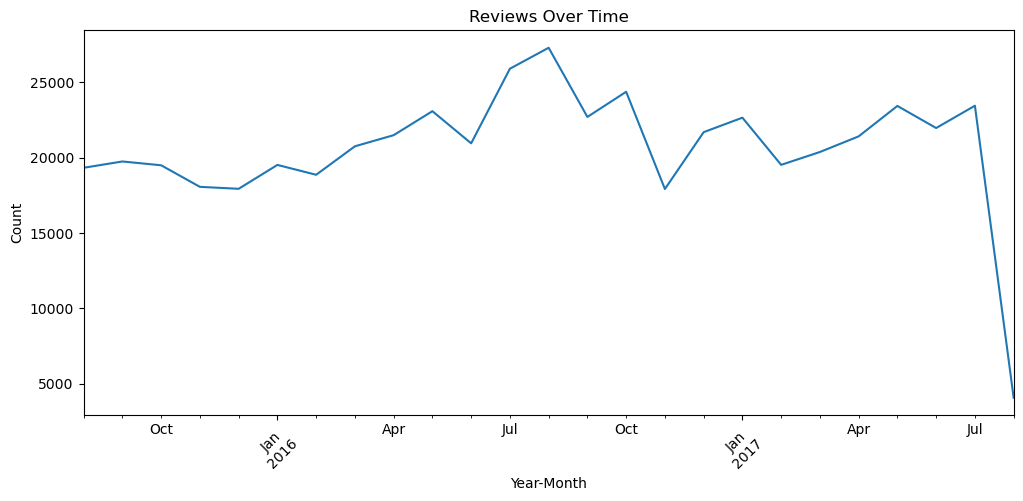

In [12]:

# Reviews Over Time
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Review_YearMonth'] = df['Review_Date'].dt.to_period('M')
df['Review_YearMonth'].value_counts().sort_index().plot(figsize=(12, 5))
plt.title('Reviews Over Time')
plt.ylabel('Count')
plt.xlabel('Year-Month')
plt.xticks(rotation=45)
plt.show()

### Combining Positive and Negative Hotel Reviews for Sentiment Analysis

This code block prepares the dataset by merging the `Positive_Review` and `Negative_Review` columns into a single column named `Review`, and assigns sentiment labels:

- **1** for positive reviews  
- **0** for negative reviews

It also removes any rows that do not contain valid positive or negative reviews (i.e., where the values are `'No Positive'` or `'No Negative'`).

This is a crucial preprocessing step to create a binary classification dataset suitable for training a sentiment analysis model.

Key steps:
- Filter out meaningless entries
- Create separate positive and negative dataframes
- Label sentiments accordingly
- Concatenate and reset index to form a unified dataset `df_all`


In [13]:
df = df[(df['Positive_Review'] != 'No Positive') & (df['Negative_Review'] != 'No Negative')]

df_pos = df[['Positive_Review']].copy()
df_pos['Sentiment'] = 1
df_pos.rename(columns={'Positive_Review': 'Review'}, inplace=True)

df_neg = df[['Negative_Review']].copy()
df_neg['Sentiment'] = 0
df_neg.rename(columns={'Negative_Review': 'Review'}, inplace=True)

df_all = pd.concat([df_pos, df_neg]).reset_index(drop=True)
df_all.head()

,Review,Sentiment
0,Only the park outside of the hotel was beauti...,1
1,Location was good and staff were ok It is cut...,1
2,Great location in nice surroundings the bar a...,1
3,Amazing location and building Romantic setting,1
4,Good restaurant with modern design great chil...,1


### Text Cleaning, Stop Word Removal & Lemmatization

This code defines a `clean_text()` function that cleans each review by:
- Converting text to lowercase
- Removing punctuation and special characters
- Splitting into words (tokenization)
- Removing common stop words (e.g., "the", "is", "and")
- Lemmatizing words (reducing them to their base form, e.g., "running" → "run")

It then applies this cleaning function to all rows in the dataset using `.apply()` and stores the result in a new column called `Cleaned_Review`.

This cleaned version of the review is essential for effective vectorization and model performance. 


In [14]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\knowl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\knowl\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df_all['Cleaned_Review'] = df_all['Review'].apply(clean_text)
df_all[['Review', 'Cleaned_Review', 'Sentiment']].head()


,Review,Cleaned_Review,Sentiment
0,Only the park outside of the hotel was beauti...,park outside hotel beautiful,1
1,Location was good and staff were ok It is cut...,location good staff ok cute hotel breakfast ra...,1
2,Great location in nice surroundings the bar a...,great location nice surroundings bar restauran...,1
3,Amazing location and building Romantic setting,amazing location building romantic setting,1
4,Good restaurant with modern design great chil...,good restaurant modern design great chill plac...,1


### Sentiment-Based Word Clouds (Positive vs Negative Reviews)

This code block generates two word clouds to visualize the most frequent terms used in:

- **Positive hotel reviews** (white background)
- **Negative hotel reviews** (black background)

Each review is pre-cleaned and tokenized. The word cloud helps visually explore what guests typically praise or complain about. Words like "clean", "friendly", or "view" might dominate positive reviews, while "dirty", "slow", or "noise" may appear in negative ones.

This visual analysis supports sentiment interpretation before building the machine learning model.


In [16]:
!pip install wordcloud


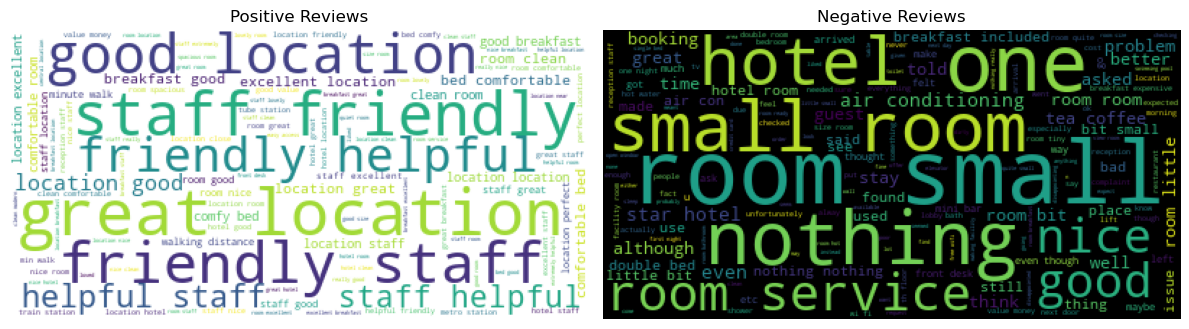

In [17]:
from wordcloud import WordCloud

wc_pos = WordCloud(background_color='white').generate(" ".join(df_all[df_all['Sentiment']==1]['Cleaned_Review']))
wc_neg = WordCloud(background_color='black').generate(" ".join(df_all[df_all['Sentiment']==0]['Cleaned_Review']))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Reviews")

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Reviews")
plt.tight_layout()
plt.show()


### Sentiment Classification with TF-IDF and Logistic Regression

This code block performs the core machine learning steps for sentiment classification:

1. **TF-IDF Vectorization**  
   Converts cleaned text into numerical vectors based on word frequency and importance.

2. **Model Building**  
   Trains a `LogisticRegression` classifier on the review data to distinguish between positive and negative sentiments.

3. **Model Evaluation**  
   Outputs classification metrics and a confusion matrix to assess performance.

This model serves as a baseline for classifying hotel reviews and can be later improved with techniques like hyperparameter tuning, cross-validation, or deep learning.


In [18]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df_all['Cleaned_Review'])
y = df_all['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92     70638
           1       0.93      0.91      0.92     70174

    accuracy                           0.92    140812
   macro avg       0.92      0.92      0.92    140812
weighted avg       0.92      0.92      0.92    140812

Confusion Matrix:
 [[65869  4769]
 [ 6018 64156]]


### ROC Curve for Model Evaluation

This code block visualizes the ROC (Receiver Operating Characteristic) curve for the logistic regression model using predicted probabilities.

The ROC curve illustrates the trade-off between **True Positive Rate** and **False Positive Rate** across different classification thresholds. The Area Under the Curve (AUC) score summarizes the model’s ability to distinguish between the two classes:

- AUC closer to **1.0** indicates excellent performance
- AUC around **0.5** indicates performance no better than random guessing

This plot is a standard diagnostic tool in binary classification problems like sentiment analysis.


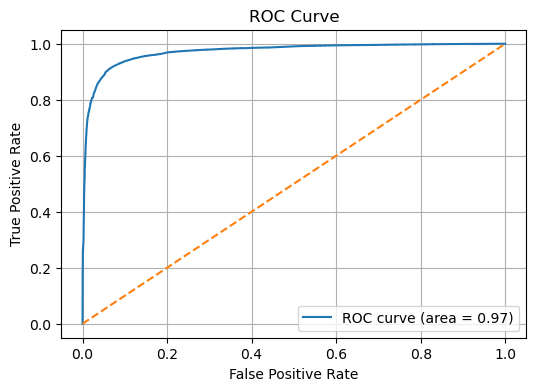

In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


### Saving the Sentiment Model and Vectorizer

This code block saves the trained `LogisticRegression` model and the fitted `TfidfVectorizer` using the `joblib` library.

- The model is saved to `../models/sentiment_model.pkl`
- The vectorizer is saved to `../models/vectorizer.pkl`

Saving these objects allows you to deploy or reuse the trained pipeline without retraining the model every time. You can load them later using `joblib.load()` for making predictions in real time or through an API.


In [25]:
import os
import joblib

# Create directory
os.makedirs('../models', exist_ok=True)

# Save model and vectorizer
joblib.dump(model, '../models/sentiment_model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print("Model and vectorizer saved.")



Model and vectorizer saved.
